c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Asus\AppData\Local\Temp\ipykernel_2076\666161422.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


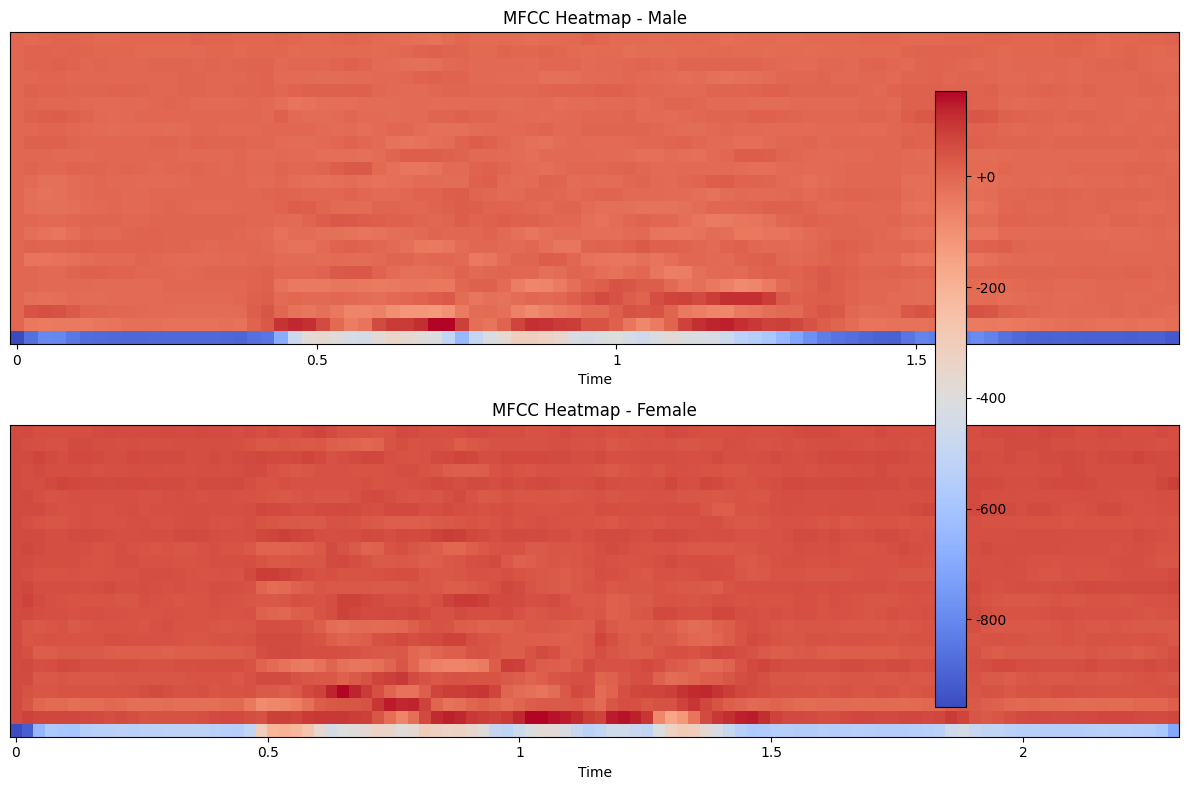

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

# ============================================================
# MFCC HEATMAP MALE & FEMALE
# ============================================================

metadata_path = 'validated.tsv'
audio_folder = 'clips'

df = pd.read_csv(
    metadata_path,
    sep='\t'
)

male_file = df[
    df["gender"] == "male_masculine"
]["path"].iloc[0]

female_file = df[
    df["gender"] == "female_feminine"
]["path"].iloc[0]

male_path = os.path.join(
    audio_folder,
    male_file
)

female_path = os.path.join(
    audio_folder,
    female_file
)


def extract_mfcc_heatmap(file_path):

    y, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    # Pre-emphasis
    pre = 0.97

    y = np.append(
        y[0],
        y[1:] - pre * y[:-1]
    )

    # MFCC 24
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=24
    )

    return mfcc, sr


mfcc_male, sr_male = extract_mfcc_heatmap(
    male_path
)

mfcc_female, sr_female = extract_mfcc_heatmap(
    female_path
)


# ============================================================
# Visualisasi
# ============================================================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(12, 8)
)


img1 = librosa.display.specshow(
    mfcc_male,
    x_axis='time',
    ax=ax[0]
)

ax[0].set_title(
    "MFCC Heatmap - Male"
)


img2 = librosa.display.specshow(
    mfcc_female,
    x_axis='time',
    ax=ax[1]
)

ax[1].set_title(
    "MFCC Heatmap - Female"
)


fig.colorbar(
    img1,
    ax=ax,
    format="%+2.0f"
)

plt.tight_layout()
plt.show()